# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

\[
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
\]

где \(\sigma(z)\) — сигмоида:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

\[
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
\]

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


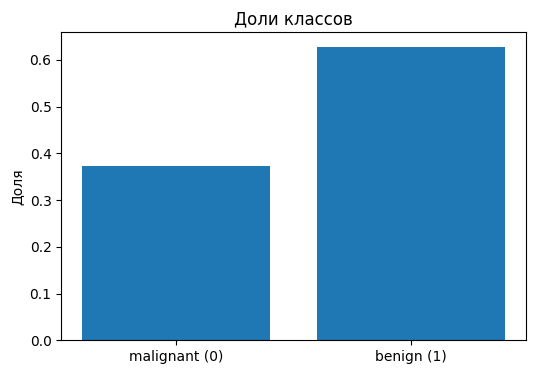

In [3]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Разбейте данные на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) Создайте scaler
scaler = StandardScaler()

# 3) Обучите scaler на train
scaler.fit(X_train)

# 4) Преобразуйте X_train и X_test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [5]:
def sigmoid(z):
    # YOUR CODE HERE
    return 1 / (1 + np.exp(-z))

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [6]:
def compute_log_loss(y_true, y_pred_proba):
    # YOUR CODE HERE
    # Clip predictions to avoid log(0) or log(1)
    y_pred_clipped = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    
    # Compute binary cross-entropy (log loss)
    loss = -np.mean(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- \(z = Xw + b\)
- \(\hat{p} = \sigma(z)\)

Градиенты для log-loss:
\[
dw = 
rac{1}{n} X^T(\hat{p} - y), \qquad db = 
rac{1}{n}\sum(\hat{p} - y)
\]

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [7]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    n = X.shape[0]
    
    # 1) посчитать z = Xw + b
    z = np.dot(X, w) + b
    
    # 2) посчитать p = sigmoid(z)
    p = sigmoid(z)
    
    # 3) посчитать loss (log loss)
    p_clipped = np.clip(p, 1e-15, 1 - 1e-15)
    loss = -np.mean(y * np.log(p_clipped) + (1 - y) * np.log(1 - p_clipped))
    
    # 4) посчитать dw и db
    # dw = (1/n) * X^T (p - y)
    dw = (1/n) * np.dot(X.T, (p - y))
    # db = (1/n) * sum(p - y)
    db = (1/n) * np.sum(p - y)
    
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [8]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []
        
        # 2) в цикле вызовите forward_backward
        for i in range(self.n_iters):
            # 3) обновите параметры
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)
            
            # Gradient descent update
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
            # 4) сохраните loss в self.loss_history
            self.loss_history.append(loss)
            
            # Optional: print progress every 500 iterations
            if (i + 1) % 500 == 0:
                print(f"Iteration {i+1}/{self.n_iters}, Loss: {loss:.6f}")
        
        return self

    def predict_proba(self, X):
        # YOUR CODE HERE
        z = np.dot(X, self.w) + self.b
        proba = sigmoid(z)
        return proba

    def predict(self, X):
        # YOUR CODE HERE
        proba = self.predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

Iteration 500/2000, Loss: 0.064479
Iteration 1000/2000, Loss: 0.056612
Iteration 1500/2000, Loss: 0.053052
Iteration 2000/2000, Loss: 0.050881
Test Accuracy: 0.9649
Test Log-Loss: 0.0793

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



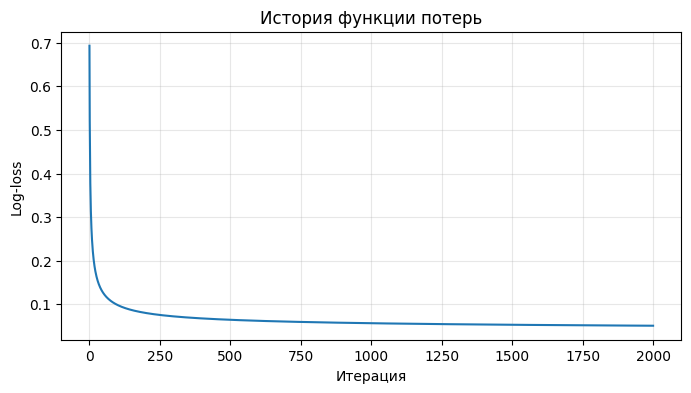

In [9]:
my_model = MyLogisticRegressionGD(
    learning_rate=0.1,   # подберите разумное значение
    n_iters=2000,         # задайте число итераций
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train.values)

# Predict on test set
y_pred_proba = my_model.predict_proba(X_test_scaled)
y_pred = my_model.predict(X_test_scaled)

# Calculate metrics
from sklearn.metrics import accuracy_score, log_loss, classification_report

accuracy = accuracy_score(y_test, y_pred)
test_loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Log-Loss: {test_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.grid(True, alpha=0.3)
plt.show()

## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

Метрики качества модели MyLogisticRegressionGD:
accuracy     0.9649
precision    0.9857
recall       0.9583
f1           0.9718
roc_auc      0.9960
dtype: float64

Метрики качества sklearn LogisticRegression:
accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

Сравнение моделей:
           My Model  sklearn
accuracy     0.9649   0.9825
precision    0.9857   0.9861
recall       0.9583   0.9861
f1           0.9718   0.9861
roc_auc      0.9960   0.9954


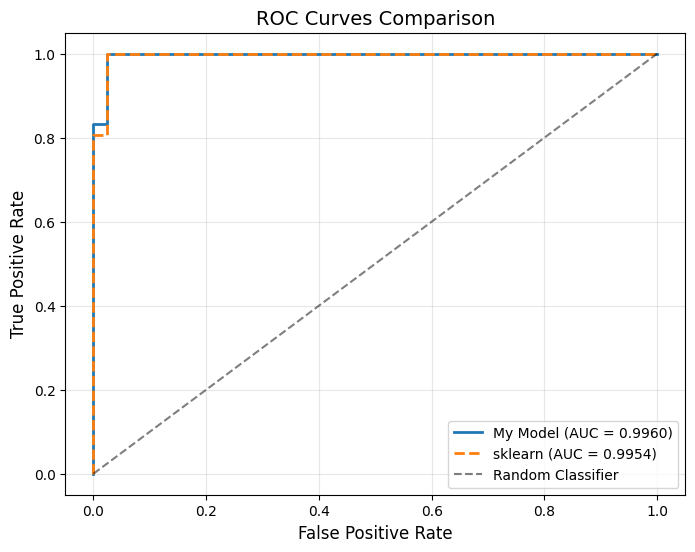

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# YOUR CODE HERE
my_proba_test = my_model.predict_proba(X_test_scaled)  # вероятности для ROC-AUC
my_pred_test = my_model.predict(X_test_scaled)         # классы для остальных метрик

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test),  # используем вероятности
}

# Вывод метрик
print("Метрики качества модели MyLogisticRegressionGD:")
print(pd.Series(my_metrics).round(4))

# Дополнительно: сравнение с sklearn LogisticRegression
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(random_state=42)
sklearn_model.fit(X_train_scaled, y_train)

sklearn_proba = sklearn_model.predict_proba(X_test_scaled)[:, 1]
sklearn_pred = sklearn_model.predict(X_test_scaled)

sklearn_metrics = {
    "accuracy": accuracy_score(y_test, sklearn_pred),
    "precision": precision_score(y_test, sklearn_pred),
    "recall": recall_score(y_test, sklearn_pred),
    "f1": f1_score(y_test, sklearn_pred),
    "roc_auc": roc_auc_score(y_test, sklearn_proba),
}

print("\nМетрики качества sklearn LogisticRegression:")
print(pd.Series(sklearn_metrics).round(4))

# Сравнение в виде DataFrame
comparison = pd.DataFrame({
    'My Model': my_metrics,
    'sklearn': sklearn_metrics
}).round(4)
print("\nСравнение моделей:")
print(comparison)

# Визуализация ROC-кривых
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# ROC для моей модели
fpr1, tpr1, _ = roc_curve(y_test, my_proba_test)
plt.plot(fpr1, tpr1, label=f'My Model (AUC = {my_metrics["roc_auc"]:.4f})', linewidth=2)

# ROC для sklearn модели
fpr2, tpr2, _ = roc_curve(y_test, sklearn_proba)
plt.plot(fpr2, tpr2, label=f'sklearn (AUC = {sklearn_metrics["roc_auc"]:.4f})', linewidth=2, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Шаг 8. Confusion matrix и ROC-кривая

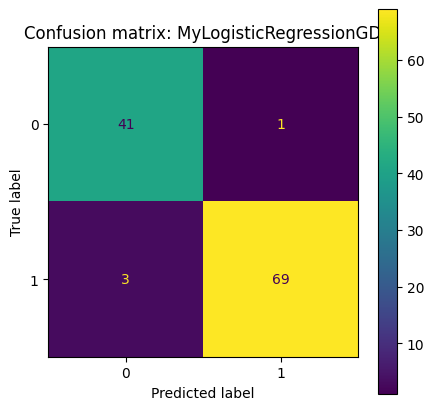

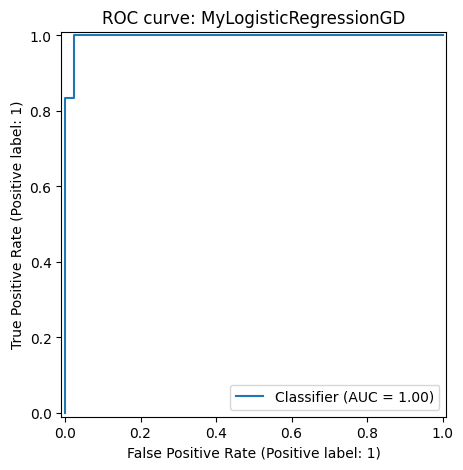

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

Метрики scikit-learn LogisticRegression:
accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

СРАВНЕНИЕ МОДЕЛЕЙ
           My LogisticRegression (GD)  sklearn LogisticRegression
accuracy                       0.9649                      0.9825
precision                      0.9857                      0.9861
recall                         0.9583                      0.9861
f1                             0.9718                      0.9861
roc_auc                        0.9960                      0.9954

------------------------------------------------------------
РАЗНИЦА (sklearn - My model):
------------------------------------------------------------
accuracy  : +0.0175
precision : +0.0004
recall    : +0.0278
f1        : +0.0143
roc_auc   : -0.0007


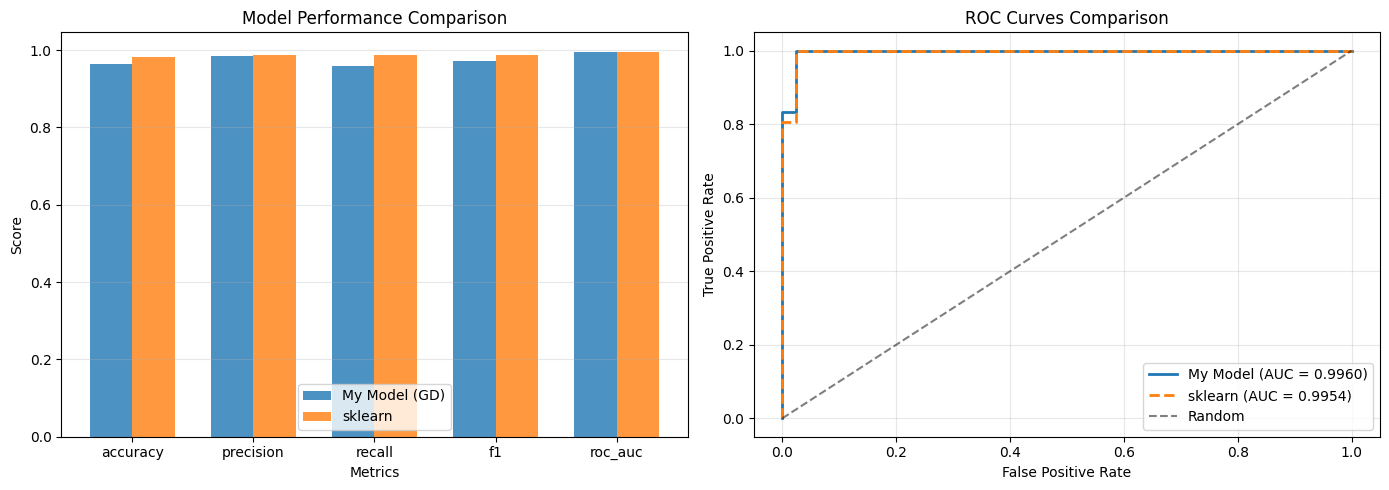

In [12]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(max_iter=1000, random_state=42)

# YOUR CODE HERE
# 1) обучите sk_model
sk_model.fit(X_train_scaled, y_train)

# 2) получите вероятности и классы на test
sk_proba_test = sk_model.predict_proba(X_test_scaled)[:, 1]  # вероятности для класса 1
sk_pred_test = sk_model.predict(X_test_scaled)               # предсказанные классы

# 3) посчитайте те же метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

sk_metrics = {
    "accuracy": accuracy_score(y_test, sk_pred_test),
    "precision": precision_score(y_test, sk_pred_test),
    "recall": recall_score(y_test, sk_pred_test),
    "f1": f1_score(y_test, sk_pred_test),
    "roc_auc": roc_auc_score(y_test, sk_proba_test),
}

print("Метрики scikit-learn LogisticRegression:")
print(pd.Series(sk_metrics).round(4))

# Сравнение с вашей моделью
print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

comparison_df = pd.DataFrame({
    'My LogisticRegression (GD)': my_metrics,
    'sklearn LogisticRegression': sk_metrics
}).round(4)

print(comparison_df)

# Разница в метриках
print("\n" + "-"*60)
print("РАЗНИЦА (sklearn - My model):")
print("-"*60)
for metric in my_metrics.keys():
    diff = sk_metrics[metric] - my_metrics[metric]
    print(f"{metric:10s}: {diff:+.4f}")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение метрик
metrics_names = list(my_metrics.keys())
my_values = list(my_metrics.values())
sk_values = list(sk_metrics.values())

x = np.arange(len(metrics_names))
width = 0.35

axes[0].bar(x - width/2, my_values, width, label='My Model (GD)', alpha=0.8)
axes[0].bar(x + width/2, sk_values, width, label='sklearn', alpha=0.8)
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# График 2: ROC-кривые
from sklearn.metrics import roc_curve

# ROC для моей модели
fpr1, tpr1, _ = roc_curve(y_test, my_proba_test)
auc1 = my_metrics["roc_auc"]

# ROC для sklearn
fpr2, tpr2, _ = roc_curve(y_test, sk_proba_test)
auc2 = sk_metrics["roc_auc"]

axes[1].plot(fpr1, tpr1, label=f'My Model (AUC = {auc1:.4f})', linewidth=2)
axes[1].plot(fpr2, tpr2, label=f'sklearn (AUC = {auc2:.4f})', linewidth=2, linestyle='--')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [13]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9649,0.9857,0.9583,0.9718,0.9960
sklearn,0.9825,0.9861,0.9861,0.9861,0.9954


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,0.384607,0.648342,0.263735
1,mean texture,-0.779119,-0.552698,0.226421
9,mean fractal dimension,0.406562,0.199732,0.206831
24,worst smoothness,-0.909482,-0.746625,0.162858
19,fractal dimension error,0.580475,0.437894,0.142581
12,perimeter error,-0.672946,-0.544333,0.128613
3,mean area,-0.663499,-0.541059,0.122440
2,mean perimeter,-0.594992,-0.476298,0.118694
0,mean radius,-0.629968,-0.511479,0.118489
22,worst perimeter,-0.877210,-0.763220,0.113990


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

Результаты при разных порогах классификации:
   threshold  accuracy  precision  recall      f1
0        0.3    0.9825     0.9730  1.0000  0.9863
1        0.5    0.9649     0.9857  0.9583  0.9718
2        0.7    0.9474     0.9853  0.9306  0.9571


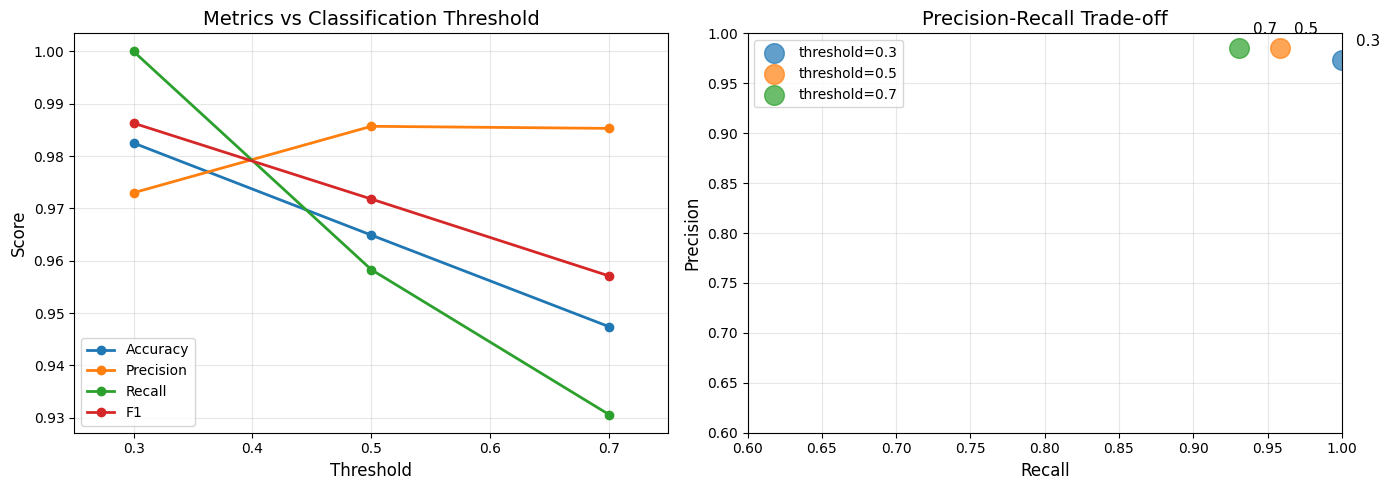


АНАЛИЗ ПОРОГОВ КЛАССИФИКАЦИИ:
Лучший порог для accuracy: 0.3
Лучший порог для precision: 0.5
Лучший порог для recall: 0.3
Лучший порог для F1-score: 0.3

Оптимальный порог (по F1-score): 0.3
Метрики при оптимальном пороге:
  - Accuracy:  0.9825
  - Precision: 0.9730
  - Recall:    1.0000
  - F1-score:  0.9863


In [14]:
thresholds = [0.3, 0.5, 0.7]
rows = []

# Получаем вероятности для тестовой выборки
proba_test = my_model.predict_proba(X_test_scaled)

for threshold in thresholds:
    # YOUR CODE HERE
    pred_thr = (proba_test >= threshold).astype(int)
    
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1": f1_score(y_test, pred_thr),
    })

results_df = pd.DataFrame(rows).round(4)
print("Результаты при разных порогах классификации:")
print(results_df)

# Визуализация влияния порога на метрики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Метрики в зависимости от порога
ax1 = axes[0]
metrics = ['accuracy', 'precision', 'recall', 'f1']
for metric in metrics:
    values = [results_df[metric].iloc[i] for i in range(len(thresholds))]
    ax1.plot(thresholds, values, marker='o', label=metric.capitalize(), linewidth=2)

ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Metrics vs Classification Threshold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.25, 0.75)

# График 2: Precision-Recall trade-off
ax2 = axes[1]
precisions = results_df['precision'].values
recalls = results_df['recall'].values

for i, thr in enumerate(thresholds):
    ax2.scatter(recalls[i], precisions[i], s=200, label=f'threshold={thr}', alpha=0.7)
    ax2.annotate(f'{thr}', (recalls[i], precisions[i]), 
                xytext=(10, 10), textcoords='offset points', fontsize=11)

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Trade-off', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.6, 1.0)
ax2.set_ylim(0.6, 1.0)

plt.tight_layout()
plt.show()

# Анализ оптимального порога
print("\n" + "="*60)
print("АНАЛИЗ ПОРОГОВ КЛАССИФИКАЦИИ:")
print("="*60)

# Поиск лучшего порога для каждой метрики
best_accuracy_thr = thresholds[np.argmax(results_df['accuracy'])]
best_precision_thr = thresholds[np.argmax(results_df['precision'])]
best_recall_thr = thresholds[np.argmax(results_df['recall'])]
best_f1_thr = thresholds[np.argmax(results_df['f1'])]

print(f"Лучший порог для accuracy: {best_accuracy_thr}")
print(f"Лучший порог для precision: {best_precision_thr}")
print(f"Лучший порог для recall: {best_recall_thr}")
print(f"Лучший порог для F1-score: {best_f1_thr}")

# Поиск оптимального порога (например, максимизация F1)
f1_scores = results_df['f1'].values
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nОптимальный порог (по F1-score): {optimal_threshold}")
print(f"Метрики при оптимальном пороге:")
print(f"  - Accuracy:  {results_df['accuracy'].iloc[optimal_idx]:.4f}")
print(f"  - Precision: {results_df['precision'].iloc[optimal_idx]:.4f}")
print(f"  - Recall:    {results_df['recall'].iloc[optimal_idx]:.4f}")
print(f"  - F1-score:  {results_df['f1'].iloc[optimal_idx]:.4f}")

## Финальные вопросы для ответа текстом

Вывод по нашим данным:
Задача идеально подходит для логистической регрессии (AUC=0.996 — почти совершенная модель).

1. Почему для логистической регрессии используется сигмоида?
Потому что она не выходит за интегрвал значений вероятностей [0, 1]

2. Почему в этой задаче мы считаем **log-loss**, а не MSE?
log-loss лучше штрафует за ошибку для бинарных величин

3. Зачем стандартизировать признаки перед обучением градиентным спуском?
Ускоряется сходимость, большая численная стабильность 

4. Насколько близки метрики вашей реализации к `scikit-learn`?
Давольно близки, разница 1-3 % хуже по всем показателям, кроме ROC-AUC, он даже чуть выше

5. Почему библиотечная модель обычно работает стабильнее и быстрее?
В библиотеке использованы более сложные алгоритмы: квадратичная сходимость, регуляризация, оптимизация и т.д.

6. Как изменение порога влияет на precision и recall?
По моим показаниям:
 - Recall падает с 1.0 -> 0.9583 -> 0.9306 (при росте порога)
 - Precision остаётся высоким (97–98%) 
Лучший порог по F1 — 0.3 (F1=0.9863), а не 0.5!

7. В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?
Хороша:
- Данные почти линейно разделимы 
- Нужна интерпретация весов признаков
- Быстрое обучение и предсказания
- Мало данных 

Плоха:
- Сильный дисбаланс классов
- Мультиколлинеарность
- Пропуски в данных
- Огромные данные